Simulaciones numéricas: modelos SIR, SIRS y SEIR

Genera:
  - Evolución temporal de los tres modelos para R0 < 1 y R0 > 1
  - Diagrama de bifurcación del modelo SIRS (I* vs R0)
  - Comparación de los tres modelos con mismo R0

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [33]:
# Guía colores
COLOR_S = "#2196F3"   # azul: susceptibles
COLOR_E = "#FF9800"   # naranja: expuestos (SEIR)
COLOR_I = "#F44336"   # rojo: infectados
COLOR_R = "#4CAF50"   # verde: recuperados

#  Sistemas


In [34]:
def sir(t, y, beta, gamma):
    S, I, R = y
    return [-beta*S*I, beta*S*I - gamma*I, gamma*I]

def sirs(t, y, beta, gamma, delta):
    S, I, R = y
    return [-beta*S*I + delta*R, beta*S*I - gamma*I, gamma*I - delta*R]

def seir(t, y, beta, sigma, gamma):
    S, E, I, R = y
    return [-beta*S*I, beta*S*I - sigma*E, sigma*E - gamma*I, gamma*I]

# Parámetros

In [35]:
gamma = 0.1
sigma = 0.2
delta = 0.05

t_span = (0, 200)
t_eval = np.linspace(*t_span, 2000)

I0 = 0.01
S0 = 1 - I0

#FIGURA 1: Evolución temporal

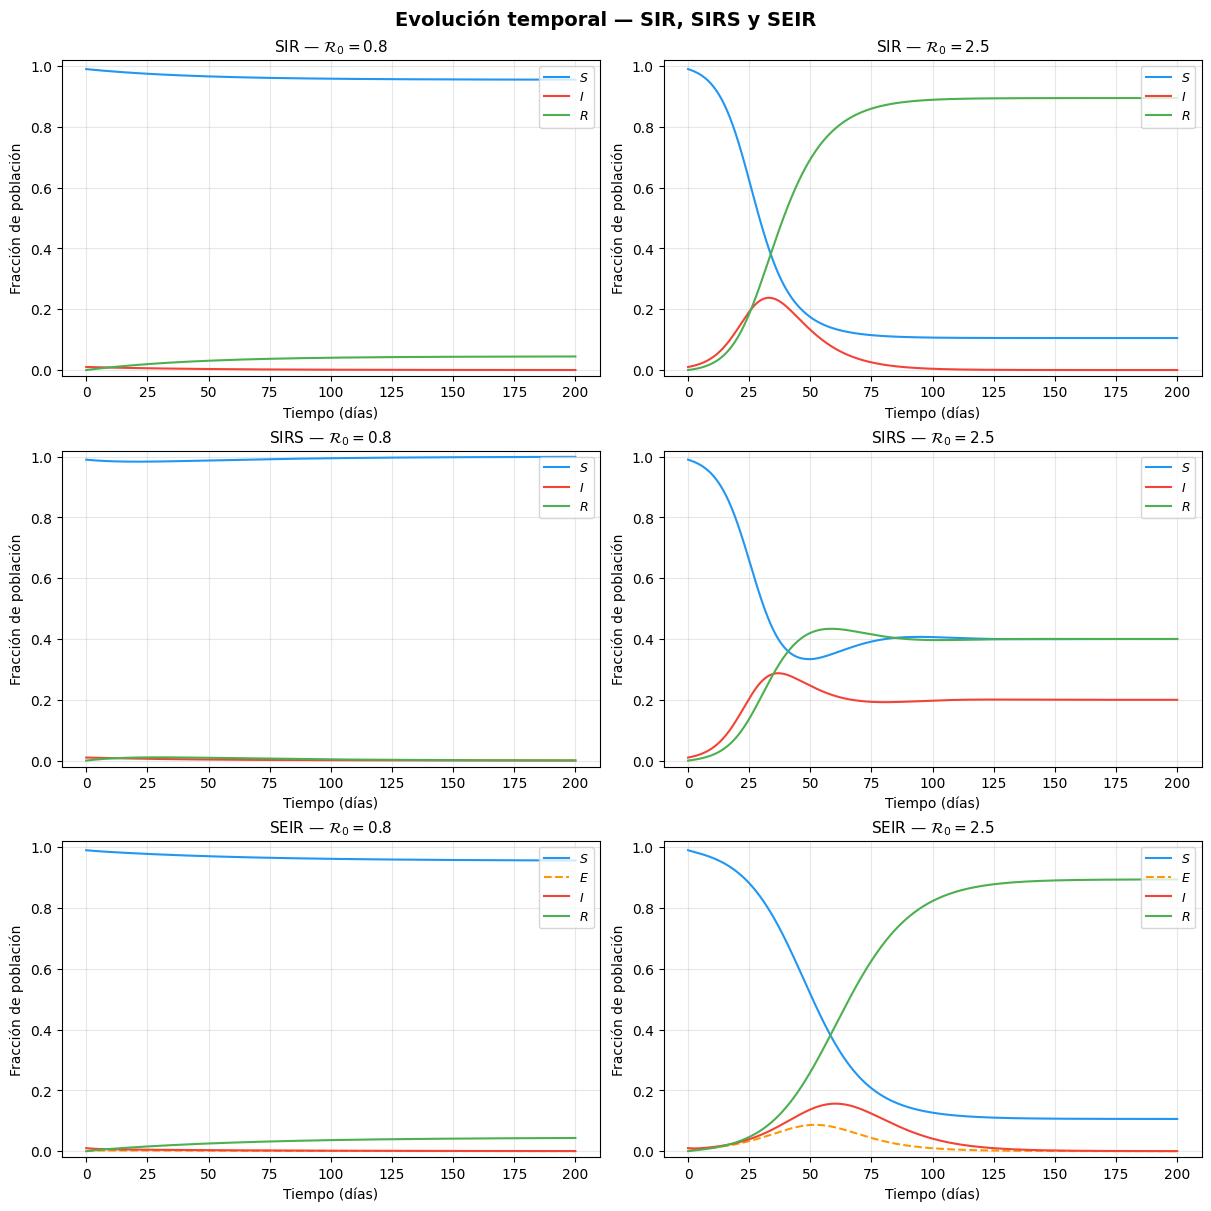

In [36]:
betas = {"$\\mathcal{R}_0 = 0.8$": 0.8 * gamma,
         "$\\mathcal{R}_0 = 2.5$": 2.5 * gamma}

model_names = ["SIR", "SIRS", "SEIR"]

fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
fig.suptitle("Evolución temporal — SIR, SIRS y SEIR", fontsize=14, fontweight="bold")

for row, model in enumerate(model_names):
    for col, (label, beta) in enumerate(betas.items()):
        ax = axes[row, col]

        if model == "SIR":
            sol = solve_ivp(sir, t_span, [S0, I0, 0.0],
                            args=(beta, gamma), t_eval=t_eval)
            ax.plot(sol.t, sol.y[0], color=COLOR_S, label="$S$")
            ax.plot(sol.t, sol.y[1], color=COLOR_I, label="$I$")
            ax.plot(sol.t, sol.y[2], color=COLOR_R, label="$R$")

        elif model == "SIRS":
            sol = solve_ivp(sirs, t_span, [S0, I0, 0.0],
                            args=(beta, gamma, delta), t_eval=t_eval)
            ax.plot(sol.t, sol.y[0], color=COLOR_S, label="$S$")
            ax.plot(sol.t, sol.y[1], color=COLOR_I, label="$I$")
            ax.plot(sol.t, sol.y[2], color=COLOR_R, label="$R$")

        else:  # SEIR
            sol = solve_ivp(seir, t_span, [S0, 0.0, I0, 0.0],
                            args=(beta, sigma, gamma), t_eval=t_eval)
            ax.plot(sol.t, sol.y[0], color=COLOR_S, label="$S$")
            ax.plot(sol.t, sol.y[1], color=COLOR_E, label="$E$", linestyle="--")
            ax.plot(sol.t, sol.y[2], color=COLOR_I, label="$I$")
            ax.plot(sol.t, sol.y[3], color=COLOR_R, label="$R$")

        ax.set_title(f"{model} — {label}", fontsize=11)
        ax.set_xlabel("Tiempo (días)")
        ax.set_ylabel("Fracción de población")
        ax.set_ylim(-0.02, 1.02)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.3)

plt.savefig("evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# FIGURA 2: Diagrama de bifurcación SIRS

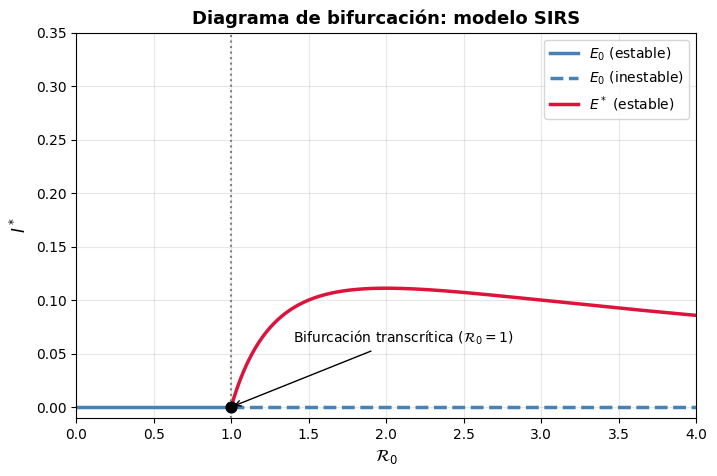

In [37]:
R0_values = np.linspace(0.01, 4.0, 500)

def I_endemico_SIRS(R0_arr, gamma, delta):
    denom = gamma * R0_arr**2 + delta * (R0_arr - 1)
    with np.errstate(invalid="ignore", divide="ignore"):
        I_star = np.where(
            (R0_arr > 1) & (denom > 0),
            delta * (R0_arr - 1) / denom,
            0.0
        )
    return I_star

I_star_vals = I_endemico_SIRS(R0_values, gamma, delta)

fig, ax = plt.subplots(figsize=(8, 5))

mask_estable   = R0_values <= 1
mask_inestable = R0_values > 1

ax.plot(R0_values[mask_estable], np.zeros_like(R0_values[mask_estable]),
        color="steelblue", linewidth=2.5, label=r"$E_0$ (estable)")
ax.plot(R0_values[mask_inestable], np.zeros_like(R0_values[mask_inestable]),
        color="steelblue", linewidth=2.5, linestyle="--", label=r"$E_0$ (inestable)")
ax.plot(R0_values[mask_inestable], I_star_vals[mask_inestable],
        color="crimson", linewidth=2.5, label=r"$E^*$ (estable)")

ax.axvline(x=1, color="gray", linestyle=":", linewidth=1.5)
ax.scatter([1], [0], color="black", zorder=5, s=60)
ax.annotate(r"Bifurcación transcrítica ($\mathcal{R}_0 = 1$)",
            xy=(1, 0), xytext=(1.4, 0.06),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=10)

ax.set_xlabel(r"$\mathcal{R}_0$", fontsize=12)
ax.set_ylabel(r"$I^*$", fontsize=12)
ax.set_title("Diagrama de bifurcación: modelo SIRS", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 4)
ax.set_ylim(-0.01, 0.35)


plt.savefig("bifurcacion_SIRS.png", dpi=150, bbox_inches="tight")

plt.show()

# FIGURA 3: Comparación de los tres modelos con R0 = 2.5

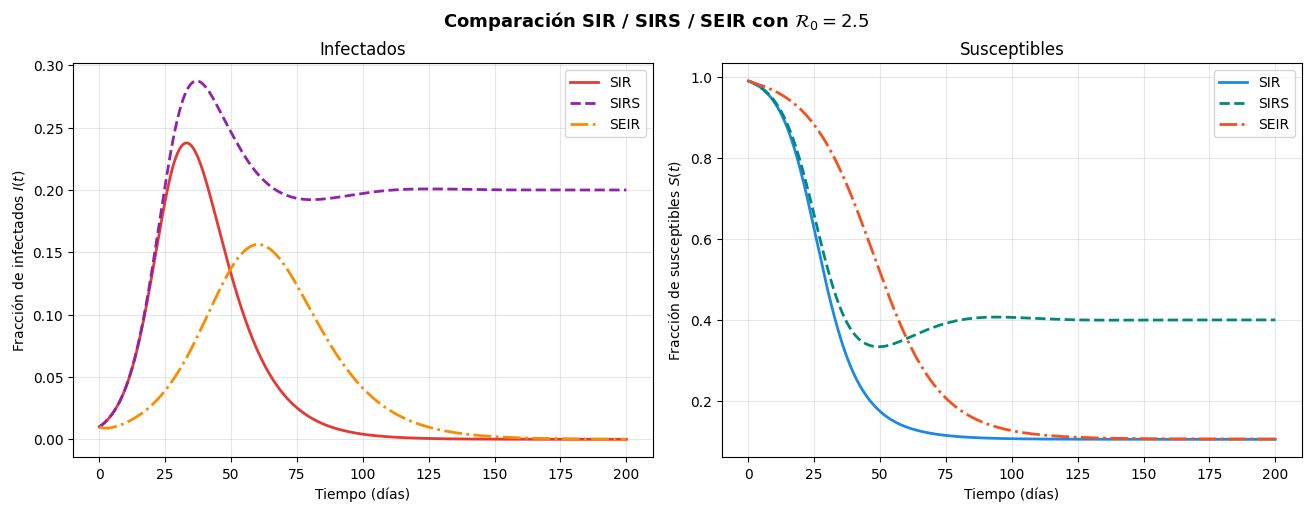

In [38]:
beta_comp = 2.5 * gamma

sol_sir  = solve_ivp(sir,  t_span, [S0, I0, 0.0],
                     args=(beta_comp, gamma), t_eval=t_eval)
sol_sirs = solve_ivp(sirs, t_span, [S0, I0, 0.0],
                     args=(beta_comp, gamma, delta), t_eval=t_eval)
sol_seir = solve_ivp(seir, t_span, [S0, 0.0, I0, 0.0],
                     args=(beta_comp, sigma, gamma), t_eval=t_eval)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle(r"Comparación SIR / SIRS / SEIR con $\mathcal{R}_0 = 2.5$",
             fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(sol_sir.t,  sol_sir.y[1],  label="SIR",  color="#E53935", linewidth=2)
ax.plot(sol_sirs.t, sol_sirs.y[1], label="SIRS", color="#8E24AA", linewidth=2, linestyle="--")
ax.plot(sol_seir.t, sol_seir.y[2], label="SEIR", color="#FB8C00", linewidth=2, linestyle="-.")
ax.set_xlabel("Tiempo (días)")
ax.set_ylabel("Fracción de infectados $I(t)$")
ax.set_title("Infectados")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sol_sir.t,  sol_sir.y[0],  label="SIR",  color="#1E88E5", linewidth=2)
ax.plot(sol_sirs.t, sol_sirs.y[0], label="SIRS", color="#00897B", linewidth=2, linestyle="--")
ax.plot(sol_seir.t, sol_seir.y[0], label="SEIR", color="#F4511E", linewidth=2, linestyle="-.")
ax.set_xlabel("Tiempo (días)")
ax.set_ylabel("Fracción de susceptibles $S(t)$")
ax.set_title("Susceptibles")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
